# Employee Attrition Analysis

## Project Overview

This project analyzes employee attrition using the IBM HR Employee Attrition dataset.

The objective is to identify patterns and factors associated with employee turnover, including department, overtime, job role, monthly income, and job satisfaction.


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


In [2]:
df = pd.read_csv("HR-Employee-Attrition.csv")

print("Dataset loaded successfully!")


Dataset loaded successfully!


In [3]:
df.shape


(1470, 35)

In [4]:
df.head()


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [6]:
df.isnull().sum()


Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

## Overall Attrition Analysis

First, we calculate the total number of employees, the number of employees who left the organization, and the overall attrition rate.


In [7]:
total_employees = len(df)

employees_left = (df["Attrition"] == "Yes").sum()

attrition_rate = employees_left / total_employees * 100

print("Total Employees:", total_employees)
print("Employees Left:", employees_left)
print("Attrition Rate:", round(attrition_rate, 2), "%")


Total Employees: 1470
Employees Left: 237
Attrition Rate: 16.12 %


## Attrition by Department

This analysis compares employee attrition rates across different departments.


In [8]:
department_attrition = (
    df.groupby("Department")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

department_attrition


Department
Sales                     20.627803
Human Resources           19.047619
Research & Development    13.839750
Name: Attrition, dtype: float64

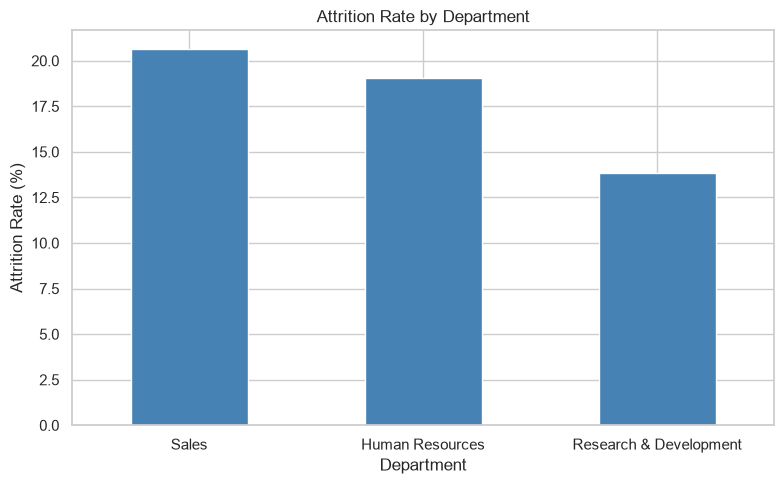

In [9]:
plt.figure(figsize=(8, 5))

department_attrition.plot(
    kind="bar",
    color="steelblue"
)

plt.title("Attrition Rate by Department")
plt.ylabel("Attrition Rate (%)")
plt.xlabel("Department")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


## Attrition by Overtime

This analysis compares attrition rates between employees who worked overtime and those who did not.


In [10]:
overtime_attrition = (
    df.groupby("OverTime")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

overtime_attrition


OverTime
No     10.436433
Yes    30.528846
Name: Attrition, dtype: float64

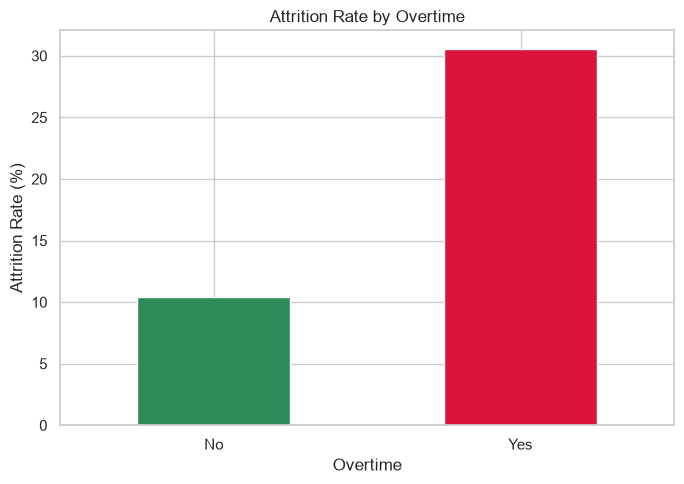

In [11]:
plt.figure(figsize=(7, 5))

overtime_attrition.plot(
    kind="bar",
    color=["seagreen", "crimson"]
)

plt.title("Attrition Rate by Overtime")
plt.ylabel("Attrition Rate (%)")
plt.xlabel("Overtime")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


## Attrition by Job Role

This analysis examines how employee attrition varies across different job roles.


In [12]:
role_attrition = (
    df.groupby("JobRole")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

role_attrition


JobRole
Sales Representative         39.759036
Laboratory Technician        23.938224
Human Resources              23.076923
Sales Executive              17.484663
Research Scientist           16.095890
Manufacturing Director        6.896552
Healthcare Representative     6.870229
Manager                       4.901961
Research Director             2.500000
Name: Attrition, dtype: float64

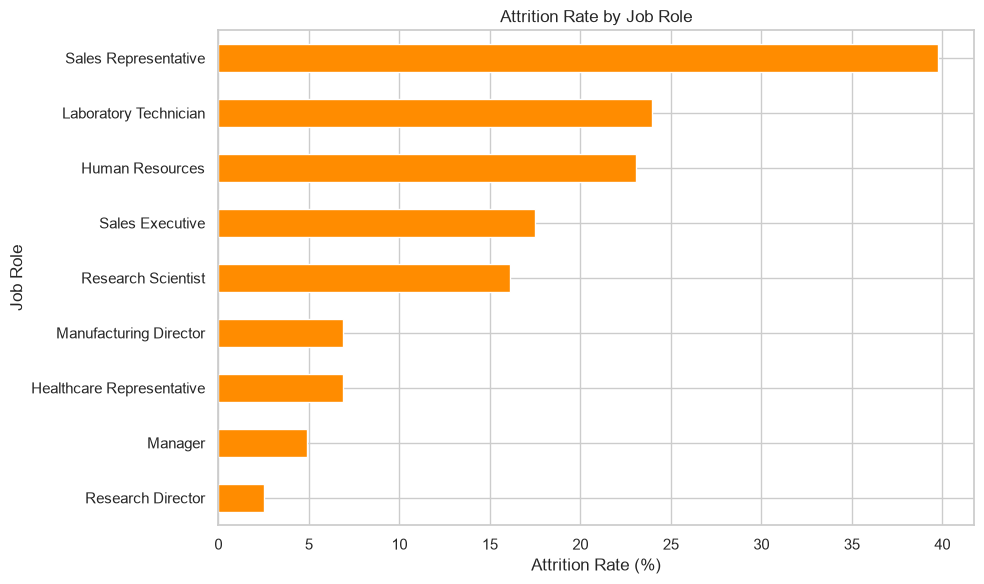

In [13]:
plt.figure(figsize=(10, 6))

role_attrition.sort_values().plot(
    kind="barh",
    color="darkorange"
)

plt.title("Attrition Rate by Job Role")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Job Role")

plt.tight_layout()
plt.show()


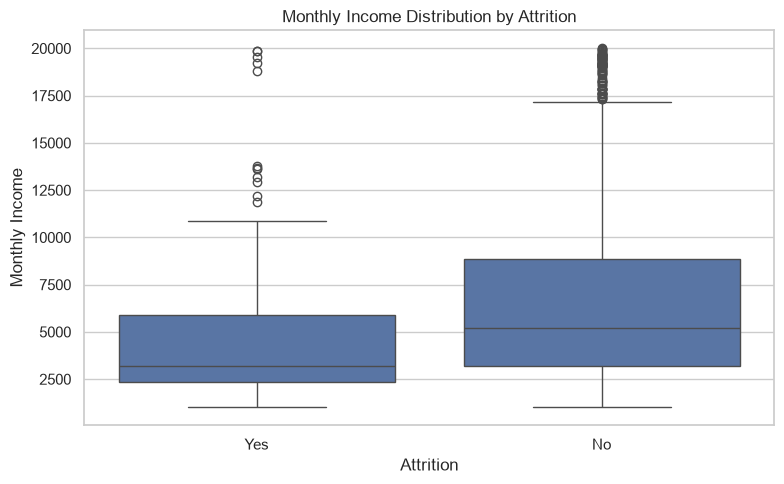

In [14]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="MonthlyIncome"
)

plt.title("Monthly Income Distribution by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")

plt.tight_layout()
plt.show()


In [15]:
income_summary = df.groupby("Attrition")["MonthlyIncome"].agg(
    ["mean", "median", "min", "max"]
)

income_summary


,mean,median,min,max
Attrition,,,,
No,6832.739659,5204.0,1051,19999
Yes,4787.092827,3202.0,1009,19859


## Job Satisfaction and Attrition

This analysis examines whether employee attrition rates differ according to job satisfaction levels.


In [16]:
satisfaction_attrition = (
    df.groupby("JobSatisfaction")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

satisfaction_attrition


JobSatisfaction
1    22.837370
2    16.428571
3    16.515837
4    11.328976
Name: Attrition, dtype: float64

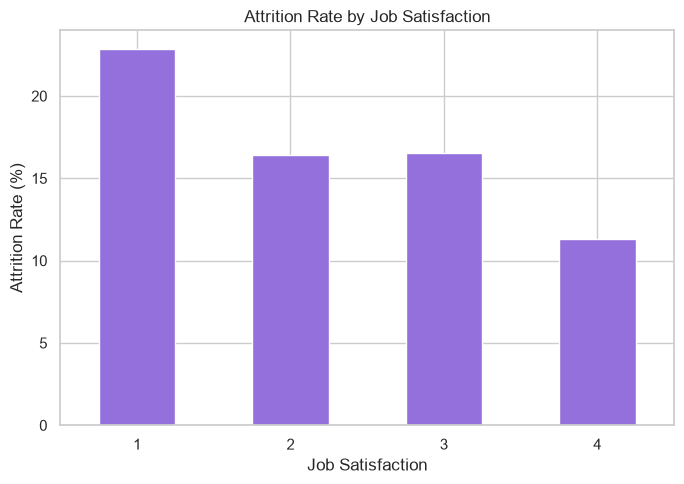

In [17]:
plt.figure(figsize=(7, 5))

satisfaction_attrition.plot(
    kind="bar",
    color="mediumpurple"
)

plt.title("Attrition Rate by Job Satisfaction")
plt.ylabel("Attrition Rate (%)")
plt.xlabel("Job Satisfaction")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


In [18]:
print("Overall Attrition Rate:")
print(round(attrition_rate, 2), "%")

print("\nAttrition Rate by Department:")
print(department_attrition.round(2))

print("\nAttrition Rate by Overtime:")
print(overtime_attrition.round(2))

print("\nAttrition Rate by Job Role:")
print(role_attrition.round(2))

print("\nAttrition Rate by Job Satisfaction:")
print(satisfaction_attrition.round(2))

print("\nMonthly Income Summary:")
print(income_summary.round(2))


Overall Attrition Rate:
16.12 %

Attrition Rate by Department:
Department
Sales                     20.63
Human Resources           19.05
Research & Development    13.84
Name: Attrition, dtype: float64

Attrition Rate by Overtime:
OverTime
No     10.44
Yes    30.53
Name: Attrition, dtype: float64

Attrition Rate by Job Role:
JobRole
Sales Representative         39.76
Laboratory Technician        23.94
Human Resources              23.08
Sales Executive              17.48
Research Scientist           16.10
Manufacturing Director        6.90
Healthcare Representative     6.87
Manager                       4.90
Research Director             2.50
Name: Attrition, dtype: float64

Attrition Rate by Job Satisfaction:
JobSatisfaction
1    22.84
2    16.43
3    16.52
4    11.33
Name: Attrition, dtype: float64

Monthly Income Summary:
              mean  median   min    max
Attrition                              
No         6832.74  5204.0  1051  19999
Yes        4787.09  3202.0  1009  19859


# Business Insights

## Finding 1: Overall Attrition

The dataset contains 1,470 employees, of whom 237 left the organization. The overall attrition rate was 16.12%.

## Finding 2: Department

Attrition was highest in the Sales department at 20.63%, followed by Human Resources at 19.05%. Research & Development had a lower attrition rate of 13.84%.

## Finding 3: Overtime

Employees who worked overtime had an attrition rate of 30.53%, compared with 10.44% among employees who did not work overtime. This shows a strong association between overtime and employee attrition.

## Finding 4: Job Role

Attrition rates varied considerably across job roles. Sales Representatives had the highest attrition rate at 39.76%, followed by Laboratory Technicians at 23.94% and Human Resources roles at 23.08%. Research Directors had the lowest attrition rate at 2.50%.

## Finding 5: Monthly Income

Employees who left the organization had lower monthly income compared with employees who stayed. The average monthly income was 4,787.09 for employees who left, compared with 6,832.74 for employees who stayed. The median monthly income was 3,202 for employees who left and 5,204 for employees who stayed. This indicates an association between monthly income and attrition; however, it does not prove that lower income directly causes employees to leave.

## Finding 6: Job Satisfaction

Employees with a job satisfaction level of 1 had the highest attrition rate at 22.84%, while employees with a satisfaction level of 4 had the lowest attrition rate at 11.33%. This suggests that lower job satisfaction is associated with higher employee attrition.

# Conclusion

The analysis indicates that employee attrition is associated with several factors, including department, overtime, job role, monthly income, and job satisfaction.

Overtime shows one of the largest differences in attrition rates, with employees who worked overtime having a much higher attrition rate than employees who did not. Sales Representatives also experienced particularly high attrition.

Employees who left the organization also had lower average and median monthly incomes than employees who stayed. In addition, lower job satisfaction was associated with higher attrition.

These findings can help organizations identify employee groups that may be at higher risk of leaving and develop strategies to improve workload management, employee satisfaction, career development opportunities, and compensation policies.
